# Power Spectrum Comparison

This notebook is intended to demonstrate we can reproduce a linear matter power spectrum generated independently by Matteo Costanzi. In order to originally reproduce it, he made a number of manual changes to the source of the CAMB CosmoSIS module, so it is important to know how to reproduce the effects of those changes.

Matteo's power spectrum is in raw files in the `ps_comparison` directory. To generate our own power spectrum, run:

```
$ cd /cosmosis/cosmosis-standard-library/y3_cluster_cpp
$ cosmosis cosmosis_tests/matteos_power_spectrum.ini
```

And output will be generated to the folder `matteos_power_spectrum`.

Text(0.5, 0, 'Power Spectrum (Mpc$^{-1}$ h)')

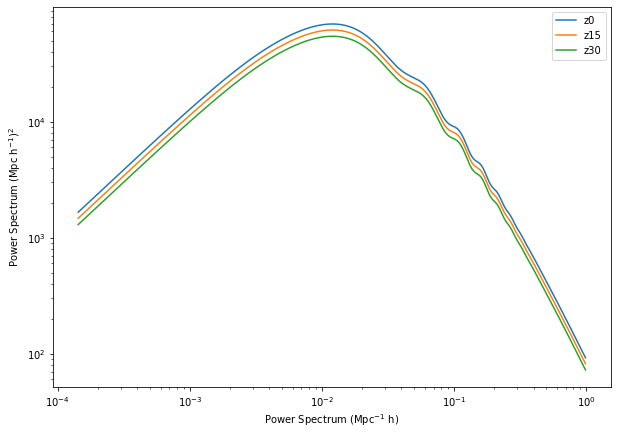

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mf_z_0_0 = np.loadtxt('ps_comparison/mf_z0.0.dat')
mf_z_0_15 = np.loadtxt('ps_comparison/mf_z0.15.dat')
mf_z_0_30 = np.loadtxt('ps_comparison/mf_z0.30.dat')

mask = mf_z_0_0[:, 0] < 1

df_matteo = pd.DataFrame({'k': mf_z_0_0[mask, 0],
                     'z0': mf_z_0_0[mask, 1],
                     'z15': mf_z_0_15[mask, 1],
                     'z30': mf_z_0_30[mask, 1]})

plt.figure('Matteos Power Spectrum', figsize=(10, 7))
ax = plt.gca()
df_matteo.plot('k', 'z0', ax=ax)
df_matteo.plot('k', 'z15', ax=ax)
df_matteo.plot('k', 'z30', ax=ax)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel('Power Spectrum (Mpc h$^{-1}$)$^2$')
ax.set_xlabel('Power Spectrum (Mpc$^{-1}$ h)')

((20, 1000),
 (701,),
 array([0.        , 0.02894737, 0.05789474, 0.08684211, 0.11578947,
        0.14473684, 0.17368421, 0.20263158, 0.23157895, 0.26052632,
        0.28947368, 0.31842105, 0.34736842, 0.37631579, 0.40526316,
        0.43421053, 0.46315789, 0.49210526, 0.52105263, 0.55      ]))

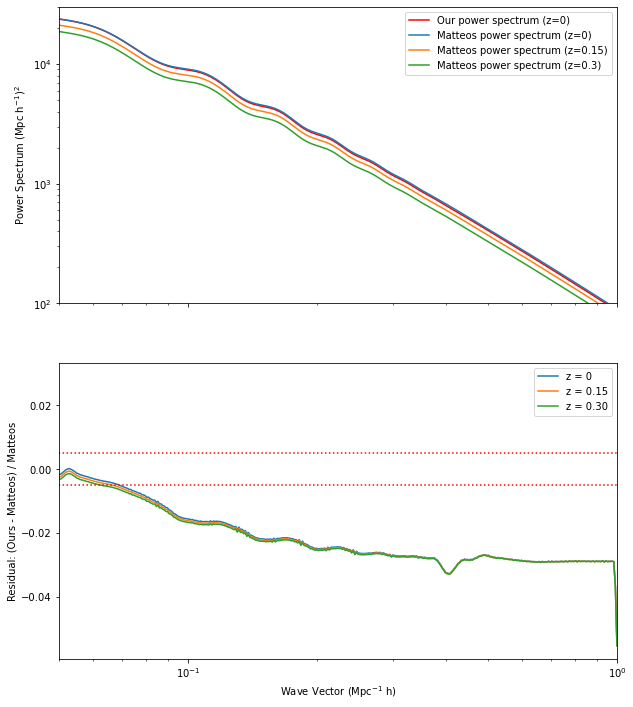

In [35]:
from scipy.interpolate import interp2d

# Load in our linear matter power spectrum
# cosmosis v1
# ours_dir = '../matteos_power_spectrum/matter_power_lin_cdm_baryon/'
# cosmosis v2 handles camb differntly
ours_dir = '../../matteos_power_spectrum/matter_de_power_lin/'
p_k = np.loadtxt(ours_dir + 'p_k.txt')
k_h = np.loadtxt(ours_dir + 'k_h.txt')
z = np.loadtxt(ours_dir + 'z.txt')


# Interpolator for ours
ours_interp = interp2d(k_h, z, p_k)

mask = (k_h > 1e-4) & (k_h < 1)
k_h = k_h[mask]
our_z0 = p_k[0,mask]
df_ours = pd.DataFrame({'k': k_h, 'z0': our_z0})

# Plot direct spectra
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(10, 12), sharex=True)
df_ours.plot('k', 'z0', c='r', ax=ax1, label='Our power spectrum (z=0)')
df_matteo.plot('k', 'z0', ax=ax1, label='Matteos power spectrum (z=0)')
df_matteo.plot('k', 'z15', ax=ax1, label='Matteos power spectrum (z=0.15)')
df_matteo.plot('k', 'z30', ax=ax1, label='Matteos power spectrum (z=0.3)')

ax1.set_ylim((our_z0.min() * 0.5, our_z0.max() * 2))

ax1.set_xscale('log')
#ax1.set_yscale('log')

ax1.set_ylabel('Power Spectrum (Mpc h$^{-1}$)$^2$')
ax1.set_xlabel('Power Spectrum (Mpc$^{-1}$ h)')

# Plot residual - need to interpolate
lnks = np.linspace(-3.7, 0, 1000)
ks = 10**lnks

matteos_z0 = np.interp(ks, df_matteo['k'], df_matteo['z0'])
matteos_z15 = np.interp(ks, df_matteo['k'], df_matteo['z15'])
matteos_z30 = np.interp(ks, df_matteo['k'], df_matteo['z30'])
ax2.plot(ks, (ours_interp(ks, 0) - matteos_z0) / matteos_z0, label='z = 0')
ax2.plot(ks, (ours_interp(ks, 0.15) - matteos_z15) / matteos_z15, label='z = 0.15')
ax2.plot(ks, (ours_interp(ks, 0.3) - matteos_z30) / matteos_z30, label='z = 0.30')

ax2.legend()
ax2.set_ylabel('Residual: (Ours - Matteos) / Matteos')
ax2.set_xlabel('Wave Vector (Mpc$^{-1}$ h)')

ax1.set_ylim((100, 30000))
ax1.set_yscale('log')
ax1.set_xlim((0.05, 1))

ax2.plot( ks, np.zeros(ks.size)+0.005, c="r", linestyle='dotted')
ax2.plot( ks, np.zeros(ks.size)-0.005, c="r", linestyle='dotted')
#ax2.set_ylim(-0.005, 0.005)

p_k.shape, k_h.shape, z